### The first cell has the code for analysing the raw sensor data to determine a suitable size for moving average window

### The second cell has the code for visualising the controller data logs to facilitate tuning


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================
df = pd.read_csv('/content/tester1.csv', encoding='latin1', sep=',', skiprows=22, header=None)

# ============================================================
# Parameters
# ============================================================
window_size = 40      # Moving average window size
start_row = 0        # Excel row 23 -> pandas index 0 (after skipping first 22 rows)

# ============================================================
# Extract Column B (second column)
# ============================================================
raw_data = 10*(df.iloc[:, 1])

# ============================================================
# Compute moving average only from row 23 onwards
# ============================================================
moving_avg = raw_data.iloc[start_row:].rolling(
    window=window_size,
    min_periods=1
).mean()

# Store in a new column
df['Moving_Average'] = None
df.loc[start_row:, 'Moving_Average'] = moving_avg.values

# ============================================================
# Plot raw data and moving average
# ============================================================
plt.figure(figsize=(12,6))

# Define the sample range for plotting
plot_start_sample = 250
plot_end_sample = 350

# Raw signal
plt.plot(
    df.index[plot_start_sample:plot_end_sample+1], # Explicitly use index for x-axis
    raw_data.iloc[plot_start_sample:plot_end_sample+1],
    label='Raw Data'
)

# Moving average
plt.plot(
    df.index[plot_start_sample:plot_end_sample+1],
    moving_avg.iloc[plot_start_sample:plot_end_sample+1],
    linewidth=2,
    label=f'{window_size}-Point Moving Average'
)

plt.xlabel('Sample Number')
plt.ylabel('Column B Value')
plt.title('Raw Data vs Moving Average (Samples 250-350)')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# ============================================================
# Optional: save result to a new CSV
# ============================================================
df.to_csv('tester1_with_moving_average.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: '/content/tester1.csv'

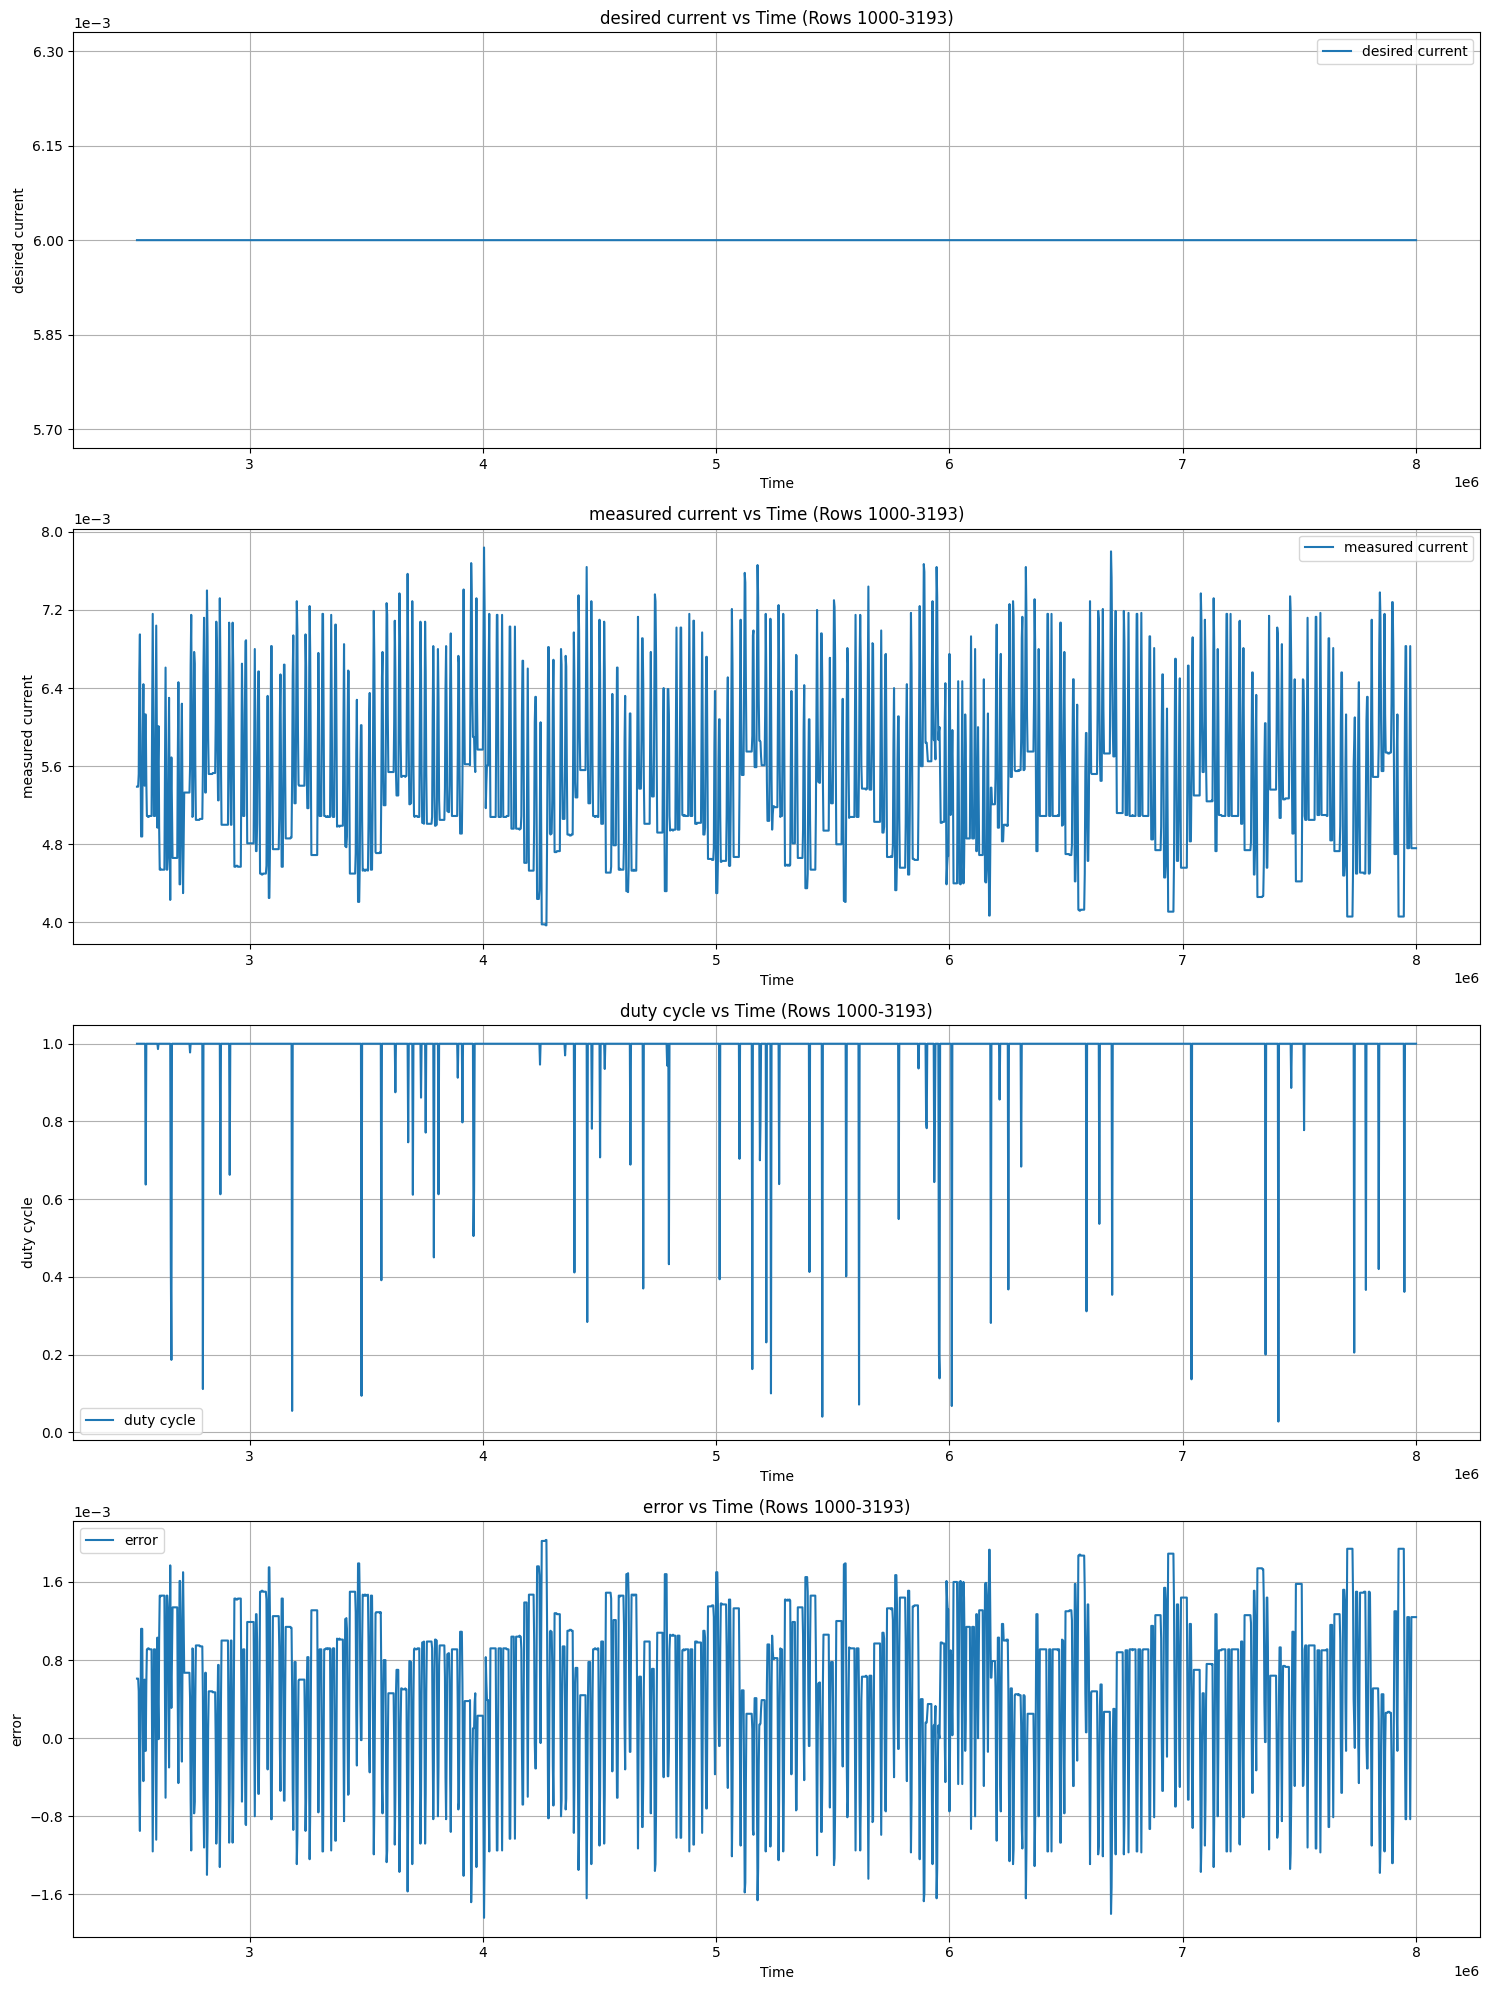

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# Load an arbitrary CSV file with specified columns
# ============================================================
# Assuming the CSV is comma-separated and has one header row to be skipped
# Adjust '/content/WITH GAINS AS KP 1000' to your file path and name if different
try:
    df_new = pd.read_csv(
        '/content/pid_50000_0_100.csv.txt',
        encoding='latin1',
        sep=',',
        header=None,
        skiprows=1,
        usecols=list(range(5)) # Explicitly read only the first 5 columns
    )
except FileNotFoundError:
    print("Error: CSV file not found. Please upload the file or specify the correct path.")
    # Create a dummy DataFrame for demonstration if the file is not found
    data = {
        0: range(0, 6000), # Time
        1: [10 + i/100 + (i%500)/1000 for i in range(6000)], # desired current
        2: [10 + i/100 + (i%450)/1000 + 0.5 * (i%100<50) for i in range(6000)], # measured current
        3: [0.5 + 0.1 * (i%300)/300 for i in range(6000)], # duty cycle
        4: [0.1 + (i%200)/200 - 0.05 for i in range(6000)]  # error
    }
    df_new = pd.DataFrame(data)
    print("Using dummy data for demonstration.")

# Convert all columns to numeric, coercing errors to NaN
df_new = df_new.apply(pd.to_numeric, errors='coerce')

# ============================================================
# Parameters for plotting
# ============================================================
plot_start_index = 1000

# Define the maximum time value for plotting (0.8 on the plot's x-axis corresponds to 8,000,000)
max_time_for_plot = 8000000

# Find the index in df_new where the time column (column 0) is <= max_time_for_plot
# and take the last such index
filtered_indices = df_new[df_new.iloc[:, 0] <= max_time_for_plot].index
if not filtered_indices.empty:
    plot_end_index = filtered_indices.max()
else:
    plot_end_index = len(df_new) - 1 # Default to end if no time value is <= max_time
    print(f"Warning: No data found up to time {max_time_for_plot}. Plotting up to the maximum available row.")

# Ensure the DataFrame has enough rows for the requested range
if len(df_new) < plot_end_index:
    print(f"Warning: The DataFrame only has {len(df_new)} rows. Plotting up to the maximum available row.")
    plot_end_index = len(df_new) - 1

# Columns to plot (index and their descriptive labels)
# Assuming: Column 0 = Time, Column 1 = desired current, Column 2 = measured current, etc.
columns_to_plot_config = [
    (0, 'Time'),
    (1, 'desired current'),
    (2, 'measured current'),
    (3, 'duty cycle'),
    (4, 'error')
]

# ============================================================
# Generate separate plots for each column
# ============================================================
fig = plt.figure(figsize=(15, len(columns_to_plot_config) * 4)) # Adjust figure size dynamically

# Extract time column using iloc for numerical index
time_data = df_new.iloc[plot_start_index:plot_end_index+1, columns_to_plot_config[0][0]]

for i, (col_idx, col_label) in enumerate(columns_to_plot_config[1:]): # Skip Time column for individual plots
    if col_idx < df_new.shape[1]: # Check if column index is within DataFrame bounds
        ax = fig.add_subplot(len(columns_to_plot_config)-1, 1, i + 1) # Create a subplot for each column
        ax.plot(
            time_data,
            df_new.iloc[plot_start_index:plot_end_index+1, col_idx],
            label=col_label
        )
        ax.set_xlabel('Time')
        ax.set_ylabel(col_label)
        ax.set_title(f'{col_label} vs Time (Rows {plot_start_index}-{plot_end_index})')
        ax.grid(True)
        ax.legend()

        # Apply MaxNLocator for general tick density control (e.g., 5-7 ticks)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

        # Apply scientific notation for y-axis labels to prevent clutter
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        # Ensure y-axis is not inverted
        if ax.yaxis.get_inverted():
            ax.invert_yaxis()
    else:
        print(f"Warning: Column index {col_idx} (for '{col_label}') is out of bounds. Skipping plot.")

plt.tight_layout()
plt.show()